# Imports Needed for Our Networks

In [1]:
# Yep, we only need one package to implement some simple NN
import numpy as np

# Graph for Solving Linear Computations

## Setting up our environment

To make the math a bit easier to follow, we'll focus on a Linear Regression implementation (rather than Logistic Regression). This has a couple of benefits:
 - We can set our problem as a simple math equation $y = X_1 + X_2 + 5$
   - This means we can know what $\hat{y}$ should be simply by looking at the inputs
 - It removes the need for the sigmoid function, making implementation a bit easier
 - It also let us explore how MSE is used as a loss function

 For this setup well use the following variables:
 - X: Inputs/Features
 - W: Weights applied to each input -> output
 - Y: Sum of the inputs (but our network doesn't know that to start)

In [2]:
np.random.seed(10)

X = np.random.randint(1, 20, size=(1000,2)) # Our inputs
W = np.random.randn(X.shape[1], 1) # Our Weights

# Our output will be the sum of the array plus five
Y = X.sum(axis=1) + 5

add_intercept = True # Do we want to add an intercept term
if add_intercept:
    # Same thing as with logistic, need a placeholder in front for intercept
    X = np.pad(X, [(0, 0), (1,0)], 'constant', constant_values=1)
    W = np.append(np.random.randn(1,1), W).reshape(X.shape[1], 1)


print(f'Our feature space:\n{X[:5]}\n')
print(f'Our outputs:\n{Y[:5]}\n')
print(f'Our initial weights:\n{W}\n')

Our feature space:
[[ 1 10  5]
 [ 1 16  1]
 [ 1 18 17]
 [ 1 18  9]
 [ 1 10  1]]

Our outputs:
[20 22 40 32 16]

Our initial weights:
[[1.65140526]
 [1.9168766 ]
 [0.25730557]]



# Feed Forward and Backpropagation
When implementing a Linear/Logistic Regression model we only needed to implement the static formula and use a static gradient calcualtion. However, when using a computational graph (or more directly a neural network) we want to abstract these steps/processes into a more generic/swappable structure.

For this reason we break down the computations of the graph into 3 separate steps:
 - **Feed Forward**: In this step we move forward through the network to calculate the prediction for the given inputs
 - **Loss Calculation**: In this step we calculate the error for the given inputs in respects to the loss function
 - **Backpropagation**: We propogate the error back through the network to update the weights so the network should produce a more accurate prediction.
   - Why can't we guarantee that the updating the weights will produce more accurate predictions?

<div style="margin:auto;width:50%;">

 ![Computational Graph Steps](https://machinelearningknowledge.ai/wp-content/uploads/2019/10/Backpropagation.gif)

</div>

***NOTE: While I talk about everything in terms of "predictions" not all networks are necessarily producing predictions, this generalization is useful at this stage as most deep learning networks focus on supervised learning.***

---

## In Class:
What is a potential benefit of abstracting these processes?

---

## Implementation
To implement this slightly tweaked structure we'll need to implement each of these steps as functions:

 - **feed_forward**: This is the step were we weight (W) our inputs (X) and aggregate them
   - $Z = \sum{X * W}$ **or** $Z = X\cdot W$
 - **mse**: This (loss function) determines the error term for our prediction
   - $\frac{\sum{(Y - \hat{Y})^2}}{N} \text{ or } \frac{\sum{(Y - Z)^2}}{N}$
 - **backprop**: This determines the gradient of our loss function and updates our weights
   - $W_{new} = W_{old} - lr * w_{grad}$
   - Rather than derviving I'll let you know that mse's derivative can be calculated using the following formula:
     - $-{X^T \cdot (Y-Z)}$

***Note: We're using MSE or Meas Squared Error for our loss function. I kept the mse name to keep our code more legible, but that function does act as our loss function***     

## In Class:
Implement the following functions

In [3]:
def feed_forward(X, W):
    """Calculates the forward pass for our network
    Args:
        X (np.array): Network inputs
        W (np.array): Network weights
    Returns: 
        np.array: weighted sum of the inputs
    """
    Z = X.dot(W)
    Z = np.dot(X, W)
    return(Z)


def mse(Z, Y):
    """Calculates the mean squared error for our predictions
    Args:
        Z (np.array): The predictions from the forward pass
        Y (np.array): The true target values
    Returns: 
        float: mean squared error of our model
    """
    mse = np.sum(np.power((Y.reshape(-1, 1)-Z), 2))/Y.shape[0]
    return mse


def backprop(X, W, Z, Y, lr):
    """Updates our model's weights based on our loss function
    Args:
        X (np.array): Network inputs
        W (np.array): Network weights
        Z (np.array): The predictions from the forward pass
        Y (np.array): The true target values
        lr (float): Learning rate for our model
    Returns: 
        np.array: The updated weights of our model after backprop
    """
    w_gradient = -X.T.dot((Y.reshape(-1, 1) - Z))
    w_gradient /= X.shape[0] # This calculates the gradient on a per feature basis
    W = W - (lr * w_gradient)
    return(W)

## Now we can use our network to perform gradient descent

We should try rerunning this later with:
 - More Test Cases
 - Lower/Higher Learning Rate
   - I use a very low learning rate so we 
 - With/Without an Intercept
 - Higher range of input values

In [4]:
def linear_regression_as_cg(X, Y, W, lr=0.00001, epochs=100, batch_size=10):
    """Train our model with the given inputs over a series of epochs
    Args:
        X (np.array): Network inputs
        W (np.array): Network weights
        Z (np.array): The predictions from the forward pass
        lr (float): Learning rate for our model
        epochs (int): The number of times to iterate over our training dataset
        batch_size (int): How many records to use per model update
    Returns: 
        np.array: the latest state of the weights generated from training
    """
    for e_ix in range(epochs):
        Z = feed_forward(X, W)
        for ix in range(int(X.shape[0]/batch_size)):
            b_start = ix * batch_size # Starting index of our next batch
            W = backprop(X[b_start:b_start+batch_size],
                                 W, Z[b_start:b_start+batch_size],
                                 Y[b_start:b_start+batch_size], lr)
        if e_ix % int(epochs/10) == 0:
            print(f'loss = {mse(Z, Y)}')
    return W

In [5]:
W = np.random.randn(X.shape[1]-1, 1) # Our Weights
add_intercept = True # Do we want to add an intercept term
if add_intercept:
    # Same thing as with logistic, need a placeholder in front for intercept
    W = np.append(np.random.randn(1,1), W).reshape(X.shape[1], 1)

pre_training_w = W.copy()
W = linear_regression_as_cg(X, Y, W, epochs=2000)

loss = 822.6802148468608
loss = 2.886676325793648
loss = 2.740133876504161
loss = 2.60181335501608
loss = 2.4704751833265464
loss = 2.345766893565126
loss = 2.227353812774105
loss = 2.114918162110908
loss = 2.008158204042
loss = 1.9067874325861185


In [6]:
print(f'''
Initial weights:
{pre_training_w}

vs

Final weights:
{W}
''')


Initial weights:
[[ 0.06825427]
 [-2.01641732]
 [ 2.22116026]]

vs

Final weights:
[[1.2678442 ]
 [1.16263576]
 [1.16409811]]



## In Class Exercise - Inferencing
Inferencing is the practice of using a model to produce an output (classification, prediction, image, text, etc.). In our case, an inference would be the numerical output of the feed foward pass.

In the cell below calculate the predictions/inference for our test dataset, then print out the first 5 records with their actual outputs. 

In [17]:
# Space for work
#np.random.seed(10)
X_test = np.random.randint(1, 20, size=(25,2))
X_test = np.pad(X_test, [(0, 0), (1,0)], 'constant', constant_values=1)

y_test = X_test.sum(axis=1) + 5 - 1

mse_test = mse(feed_forward(X_test,W),y_test)
print(mse_test)


1.477125538520501


## Evaluating Our Model
On top of using a test dataset, we can also plot our data to get a better understanding of it's performance.

(150, 2)


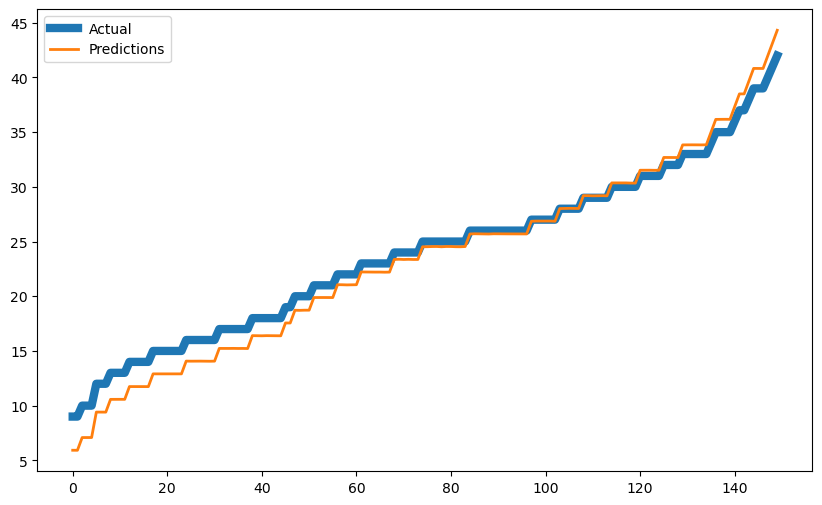

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10,6)

X = np.random.randint(1, 20, size=(150,2))
Y = X.sum(axis=1) + 5

add_intercept = True # Do we want to add an intercept term
if add_intercept:
    # Same thing as with logistic, need a placeholder in front for intercept
    X = np.pad(X, [(0, 0), (1,0)], 'constant', constant_values=1)

preds = feed_forward(X, W).reshape(-1, )

df = pd.DataFrame({'Actual': Y, 'Predictions': preds})
print(df.shape)
df.sort_values(['Actual'], inplace=True)
df.reset_index(inplace=True)

plt.plot(df['Actual'], linewidth=6.0, label='Actual')
plt.plot(df['Predictions'], linewidth=2.0, label='Predictions')
plt.legend(loc="upper left")
plt.show()


## Questions:
 - Why is the model more accurate for numbers found at the center of our range?
    - Hint, think about probabilities and distributions.
 - What would happen if we tested against negative numbers?
   - What about really large numbers?


---
## Let's rerun with a couple of edits to our epochs, lr, etc.

## In Class Exercise
Implement a test to evaluate the models performance against negative numbers or numbers larger than 100.

In [ ]:
# Space for work


---
# Setting up our environment - V2 (Products)
 - X: Inputs/Features
 - W: Weights applied to each input -> output
 - Y: Product of the inputs (but our network doesn't know that to start)

In [ ]:
np.random.seed(8)

X = np.random.randint(1, 100, size=(200,2))
#X = np.array([[0,1],[4,2],[6,3],[3,8],[2,4]])
W = 3 * np.random.randn(X.shape[1], 1)
Y = X.prod(axis=1)

add_intercept = True # Do we want to add an intercept term
if add_intercept:
    # Same thing as with logistic, need a placeholder in front for intercept
    X = np.pad(X, [(0, 0), (1,0)], 'constant', constant_values=1)
    W = np.append(3 * np.random.randn(1,1), W).reshape(X.shape[1], 1)

print(X[:5])
print(Y[:5])
print(W)

## When performing gradient descent on these inputs our model stagnats at a high error term. Why?
You might recall some of our earlier conversations regarding LLMs and multiplication.

In [ ]:

W = linear_regression_as_cg(X, Y, W, epochs=50000, batch_size=100, lr=1e-4)
        
print(f'\nOur inputs:\n{X[:5]}\n')
print(f'Our predictions:\n{feed_forward(X, W)[:5]}\n')
print(f'Our actual:\n{Y[:5]}\n')
print(f'Our resulting weights:\n{W}\n')